In [2]:
import pandas as pd
import matplotlib.pyplot as plt

master = pd.read_csv(
    "/app/data/cleaned/master_table.csv",
    parse_dates=["appointment_date","treatment_date","bill_date","date_of_birth"]
)
master['hour'] = pd.to_datetime(
    master['appointment_time'],
    format='%H:%M:%S',
    errors='coerce'
).dt.hour

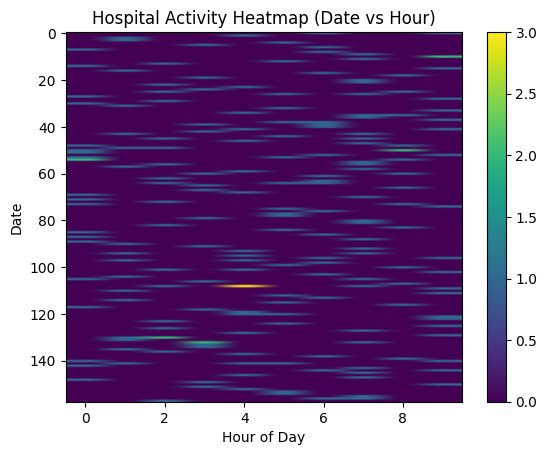

In [3]:
pivot = master.pivot_table(
    index=master['appointment_date'],
    columns='hour',
    values='appointment_id',
    aggfunc='count',
    fill_value=0
)

plt.figure()
plt.imshow(pivot, aspect='auto')
plt.title("Hospital Activity Heatmap (Date vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Date")
plt.colorbar()
plt.show()

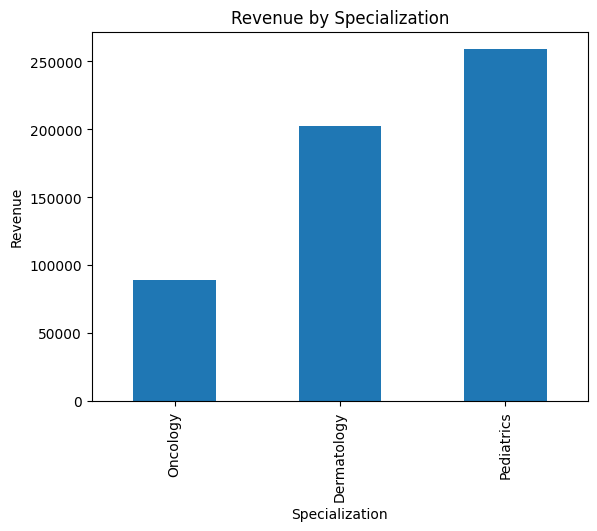

In [4]:
rev_spec = master.groupby('specialization')['amount'].sum().sort_values()

plt.figure()
rev_spec.plot(kind='bar')
plt.title("Revenue by Specialization")
plt.xlabel("Specialization")
plt.ylabel("Revenue")
plt.show()

<Figure size 640x480 with 0 Axes>

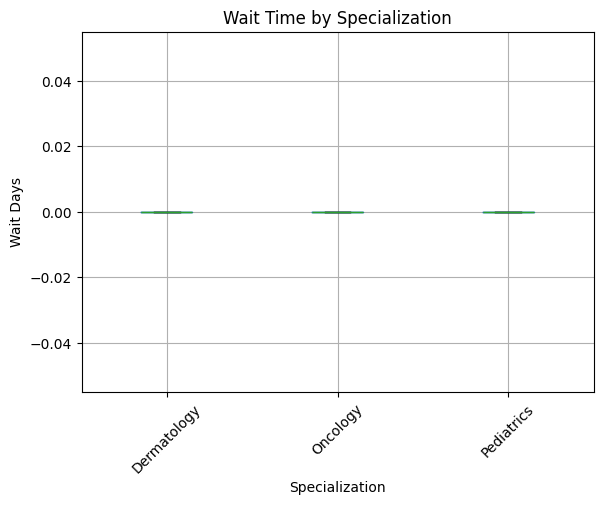

In [5]:
master['wait_days'] = (master['treatment_date'] - master['appointment_date']).dt.days

plt.figure()
master.boxplot(column='wait_days', by='specialization', rot=45)
plt.title("Wait Time by Specialization")
plt.suptitle("")
plt.xlabel("Specialization")
plt.ylabel("Wait Days")
plt.show()

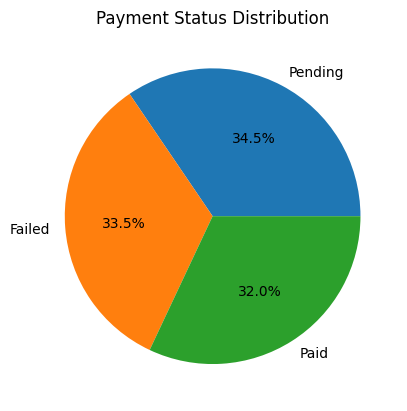

In [6]:
pay = master['payment_status'].value_counts()

plt.figure()
pay.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Status Distribution")
plt.ylabel("")
plt.show()

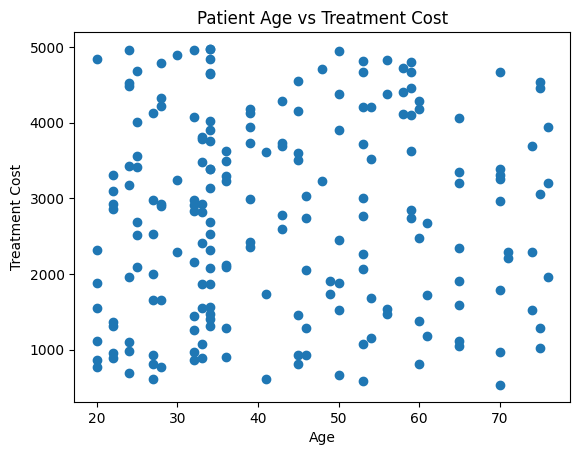

In [7]:
plt.figure()
plt.scatter(master['age'], master['cost'])
plt.title("Patient Age vs Treatment Cost")
plt.xlabel("Age")
plt.ylabel("Treatment Cost")
plt.show()